<a href="https://colab.research.google.com/github/arindamkr/Skills4India_Internship/blob/main/Bank_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**​Project Title: Bank Customer Churn Prediction**
​Objective: To develop a machine learning model that predicts whether a bank customer will leave the bank (churn) based on their demographic and financial data.
​Methodology:
​Data Collection: Importing structured tabular data.
​Data Preprocessing: Handling categorical variables and scaling numerical features to prepare them for the machine learning model.
​Model Training: Using a Random Forest Classifier, which is robust and highly effective for tabular data.
​Evaluation: Measuring model performance using accuracy scores and a confusion matrix.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset directly from YBI Foundation GitHub repository
url = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv'
df = pd.read_csv(url)

# Display the first 5 rows to understand the data structure
print("Dataset Head:")
display(df.head())

Dataset Head:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Data Preprocessing**
In this step, we will clean the dataset by removing irrelevant columns (like names and IDs) that do not affect the prediction. We will also convert text-based categories (like Geography and Gender) into numerical values using "dummy variables" so the machine learning model can understand them.

In [2]:
# Drop columns that are not useful for predicting churn
# 'CustomerId' and 'Surname' are unique identifiers and don't hold predictive value
df_cleaned = df.drop(['CustomerId', 'Surname'], axis=1)

# Separate the features (X) and the target variable (y)
X = df_cleaned.drop('Churn', axis=1)
y = df_cleaned['Churn']

# Convert categorical variables (Geography, Gender) into numerical format
X = pd.get_dummies(X, drop_first=True)

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the numerical features so all values are on a similar scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete. Training shape:", X_train_scaled.shape)

Data preprocessing complete. Training shape: (7000, 11)


**Implementing the Solution:** Model Training
We will train a Random Forest Classifier. This algorithm creates multiple decision trees and merges them together to get a more accurate and stable prediction.

In [3]:
# Initialize the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


**Project Evaluation**
To determine how well our model performs, we will test it against the unseen data (X_test). We will evaluate it using an accuracy score and visualize where the model makes errors using a confusion matrix.

Model Accuracy: 86.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      2416
           1       0.76      0.47      0.58       584

    accuracy                           0.87      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.86      0.87      0.85      3000



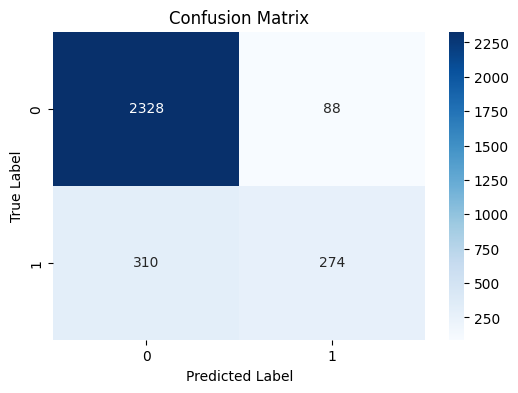

In [4]:
# Make predictions on the testing set
y_pred = model.predict(X_test_scaled)

# Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Print the detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**​Project Documentation:** Overcoming Challenges
​Challenge Faced: Dealing with categorical data (text columns like Geography and Gender). Machine learning models require numerical input, so passing raw text would result in a structural error.
​Solution Implemented: I utilized the pd.get_dummies() function from the Pandas library to perform one-hot encoding. This converted the categories into binary numeric columns, allowing the Random Forest algorithm to process the data efficiently.
​Challenge Faced: Features in the dataset had vastly different ranges (e.g., Age vs. Bank Balance).
​Solution Implemented: I applied StandardScaler from Scikit-Learn to normalize the feature scales, ensuring that larger numerical values did not unfairly dominate the model's decision-making process.